<a href="https://colab.research.google.com/github/nesredingebeyehu15-dot/My-AI-Engineering-Journey/blob/main/Day_10_Real_Project_Ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. RAW DATA RECEIVED ---


,Order_ID,Date,Cust_ID,Product,Price,Quantity
0,ORD-001,2024-01-15,101,Laptop,$1000,1.0
1,ORD-002,2024-01-16,102,Mouse,20 USD,5.0
2,ORD-003,2024/01/17,103,Monitor,$150,2.0


,Cust_ID,Name,City
0,101,abebe,Addis Ababa
1,102,SARA,Jimma
2,103,Tola,Addis Ababa



--- 2. DATA CLEANED ---


,Order_ID,Date,Cust_ID,Product,Price,Quantity
0,ORD-001,2024-01-15,101,Laptop,1000,1.0
1,ORD-002,2024-01-16,102,Mouse,20,5.0
2,ORD-003,2024-01-17,103,Monitor,150,2.0


...


>>> Q1: TOTAL REVENUE: $2,590.00

>>> Q2: SALES BY CITY:


,Total_Sales
City,
Addis Ababa,1300.0
Jimma,1100.0
Bahir Dar,190.0



>>> Q3: BEST SELLING PRODUCTS:


,Quantity
Product,
Mouse,5.0
Keyboard,3.8
Laptop,2.0
Monitor,2.0


/tmp/ipython-input-2957788733.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sales.index, y=city_sales.values, palette='viridis')


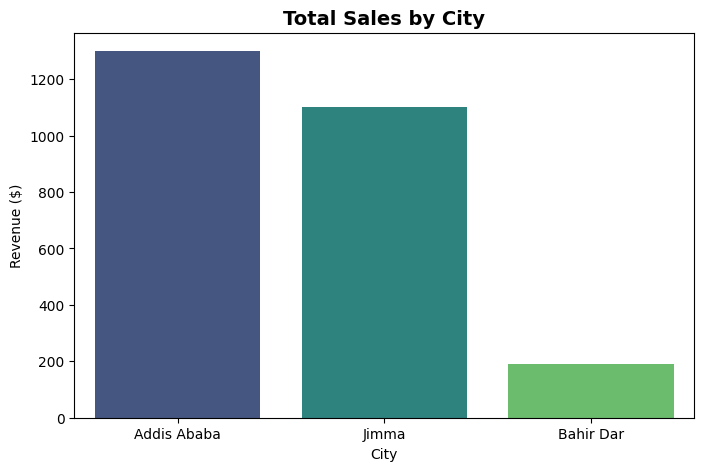

In [2]:
# DAY 10: THE E-COMMERCE DISASTER (SOLVED - PROFESSIONAL EDITION)
# Author: Nesredin Gebeyehu
# Objective: Clean, Merge, and Analyze Sales Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DATA GENERATION (RAW DATA)
# ==========================================
orders_data = {
    'Order_ID': ['ORD-001', 'ORD-002', 'ORD-003', 'ORD-002', 'ORD-004', 'ORD-005', 'ORD-006'],
    'Date': ['2024-01-15', '2024-01-16', '2024/01/17', '2024-01-16', 'Jan 18, 2024', '2024-01-20', '2024-01-21'],
    'Cust_ID': [101, 102, 103, 102, 104, 105, 999],
    'Product': [' Laptop', 'Mouse', 'Monitor ', 'Mouse', 'Keyboard', 'Laptop', 'Cable'],
    'Price': ['$1000', '20 USD', '$150', '20', '$50', '$1000', '$10'],
    'Quantity': [1, 5, 2, 5, np.nan, 1, 10]
}

customers_data = {
    'Cust_ID': [101, 102, 103, 104, 105],
    'Name': ['  abebe ', 'SARA', 'Tola', 'marta', 'Zewdu'],
    'City': ['Addis Ababa', 'Jimma', 'Addis Ababa', 'Bahir Dar', 'Jimma']
}

df_orders = pd.DataFrame(orders_data)
df_customers = pd.DataFrame(customers_data)

print("--- 1. RAW DATA RECEIVED ---")
display(df_orders.head(3))
display(df_customers.head(3))

# ==========================================
# 2. DATA CLEANING (THE JANITOR)
# ==========================================

# --- A. Cleaning Orders ---
# 1. Drop Duplicates based on Order_ID (Critical!)
df_orders = df_orders.drop_duplicates(subset=['Order_ID'])

# 2. Clean Price (Remove symbols & convert)
# Chaining methods makes code cleaner
df_orders['Price'] = df_orders['Price'].str.replace('$', '').str.replace('USD', '').str.strip()
df_orders['Price'] = pd.to_numeric(df_orders['Price'])

# 3. Clean Product Names (Remove spaces) - YOU MISSED THIS
df_orders['Product'] = df_orders['Product'].str.strip()

# 4. Handle Missing Quantity (Fill with Mean)
mean_qty = df_orders['Quantity'].mean()
df_orders['Quantity'] = df_orders['Quantity'].fillna(mean_qty)

# 5. Fix Date Format
df_orders['Date'] = pd.to_datetime(df_orders['Date'], format='mixed')

# --- B. Cleaning Customers ---
# 1. Clean Names (Strip & Title Case)
df_customers['Name'] = df_customers['Name'].str.strip().str.title()

print("\n--- 2. DATA CLEANED ---")
display(df_orders.head(3))
display(df_customers.head(3))

# ==========================================
# 3. MERGING & ANALYSIS (THE INTELLIGENCE)
# ==========================================

# 1. Inner Join (Only valid customers)
df_merged = pd.merge(df_orders, df_customers, on='Cust_ID', how='inner')

# 2. Feature Engineering (Total Sales)
df_merged['Total_Sales'] = df_merged['Price'] * df_merged['Quantity']

print("\n--- 3. MERGED DATASET ---")
display(df_merged)

# --- ANSWERING CLIENT QUESTIONS ---

# Q1: Total Revenue
total_revenue = df_merged['Total_Sales'].sum()
print(f"\n>>> Q1: TOTAL REVENUE: ${total_revenue:,.2f}")

# Q2: Top City by Sales
city_sales = df_merged.groupby('City')['Total_Sales'].sum().sort_values(ascending=False)
print("\n>>> Q2: SALES BY CITY:")
display(city_sales)

# Q3: Best Selling Product (By Quantity)
product_sales = df_merged.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
print("\n>>> Q3: BEST SELLING PRODUCTS:")
display(product_sales)

# ==========================================
# 4. VISUALIZATION (THE BONUS)
# ==========================================
plt.figure(figsize=(8, 5), facecolor='white')
# Corrected: X=City, Y=Total_Sales
sns.barplot(x=city_sales.index, y=city_sales.values, palette='viridis')

plt.title('Total Sales by City', fontsize=14, fontweight='bold')
plt.ylabel('Revenue ($)')
plt.xlabel('City')
plt.show()